In [12]:
import pandas as pd
from torch.utils.data import DataLoader
from dataset_loader import TrajectoryDataset
from models.cnn_model import CNNModel
import torch

In [13]:
df = pd.read_csv("dataset/processed_data_sim/isolate_axis.csv")
test_dataset = TrajectoryDataset(
    df, 
    window_length=15, 
    target_length=20,
    stride=100
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, 
    shuffle=False
)

dt = 0.016 
loaded_model = CNNModel(dt=dt)

save_path = "saved_models/cnn_last_Apr19_21-16-47.pth"
loaded_model.load_state_dict(torch.load(save_path, weights_only=True))
loaded_model.eval()

device = torch.device("cpu")
loaded_model = loaded_model.to(device)

In [14]:
import torch
import matplotlib.pyplot as plt

def plot_model_evaluation(model, dataloader, device="cpu", num_plots=1):
    """
    Pulls samples from the dataloader, predicts the future trajectory autoregressively, 
    and plots the History, Ground Truth, and Prediction.
    """
    model.eval()
    
    # Create an iterator to pull batches
    data_iter = iter(dataloader)
    
    for i in range(num_plots):
        try:
            input_states, input_cmds, target_states, future_cmds = next(data_iter)
        except StopIteration:
            print("No more data in dataloader.")
            break
            
        with torch.no_grad():
            # 1. Move to device and convert to tensors
            curr_state_seq = input_states.as_tensor().to(device)
            curr_cmd_seq = input_cmds.as_tensor().to(device)
            
            target_state_seq = target_states.as_tensor().to(device)
            future_cmd_seq = future_cmds.as_tensor().to(device)
            
            target_length = target_state_seq.shape[1]
            predictions = []
            
            # Save original history for plotting
            history_np = curr_state_seq.cpu().numpy()
            
            # 2. Autoregressive Prediction Loop
            for t in range(target_length):
                # Predict next step
                pred_state = model(curr_state_seq, curr_cmd_seq)
                pred_state_tensor = pred_state.as_tensor().unsqueeze(1)
                predictions.append(pred_state_tensor)
                
                # Roll windows forward
                curr_state_seq = torch.cat([curr_state_seq[:, 1:, :], pred_state_tensor], dim=1)
                next_cmd = future_cmd_seq[:, t:t+1, :]
                curr_cmd_seq = torch.cat([curr_cmd_seq[:, 1:, :], next_cmd], dim=1)
                
            # Combine all predictions
            all_predictions = torch.cat(predictions, dim=1).cpu().numpy()
            target_states_np = target_state_seq.cpu().numpy()
            
        # 3. Extract X (index 0) and Y (index 1) arrays
        # Shape is (batch_size, sequence_length, features). Since batch_size=1, we use index 0.
        hist_x = history_np[0, :, 0]
        hist_y = history_np[0, :, 1]
        
        true_fut_x = target_states_np[0, :, 0]
        true_fut_y = target_states_np[0, :, 1]
        
        pred_fut_x = all_predictions[0, :, 0]
        pred_fut_y = all_predictions[0, :, 1]
        
        # 4. Plotting
        plt.figure(figsize=(10, 8))
        
        # Plot History
        plt.plot(hist_x, hist_y, color='black', marker='.', linestyle='-', 
                 linewidth=2, label='Previous Trajectory (History)', alpha=0.6)
        
        # Highlight the starting point for predictions
        plt.plot(hist_x[-1], hist_y[-1], 'ko', markersize=8, label='Current Position')
        
        # Plot Ground Truth
        # Connect it from the last historical point for visual continuity
        gt_x = [hist_x[-1]] + list(true_fut_x)
        gt_y = [hist_y[-1]] + list(true_fut_y)
        plt.plot(gt_x, gt_y, color='green', marker='.', linestyle='--', 
                 linewidth=2, label='Ground Truth Future', markersize=8)
        
        # Plot Prediction
        pred_x = [hist_x[-1]] + list(pred_fut_x)
        pred_y = [hist_y[-1]] + list(pred_fut_y)
        plt.plot(pred_x, pred_y, color='red', marker='.', linestyle='-', 
                 linewidth=2, label='Predicted Future', markersize=8)
        
        plt.title(f"Trajectory Prediction Evaluation (Sample {i+1})")
        plt.xlabel("Global X Position (m)")
        plt.ylabel("Global Y Position (m)")
        
        plt.axis('equal') # Prevents turns from looking squished or warped
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.show()

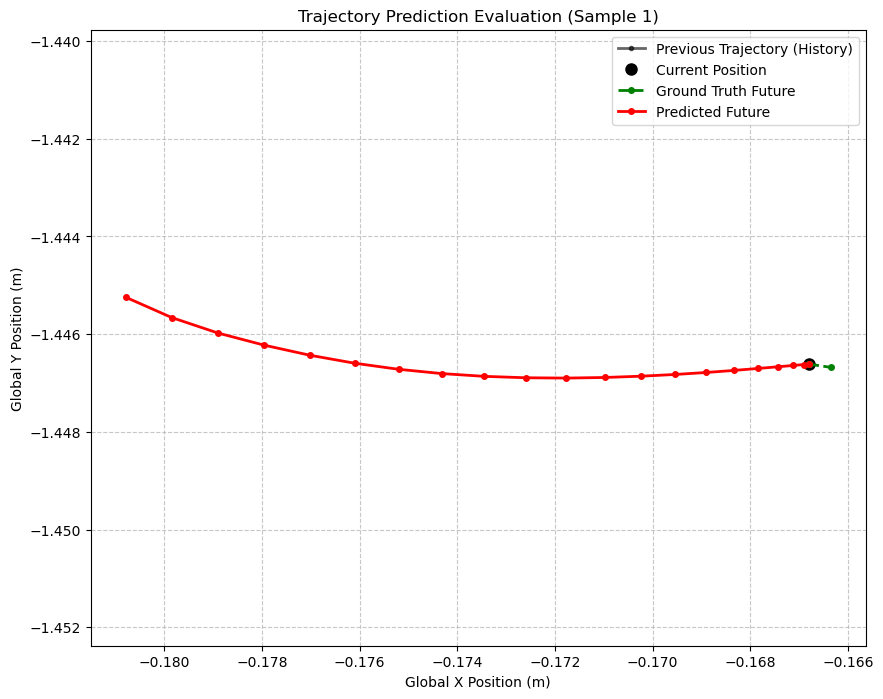

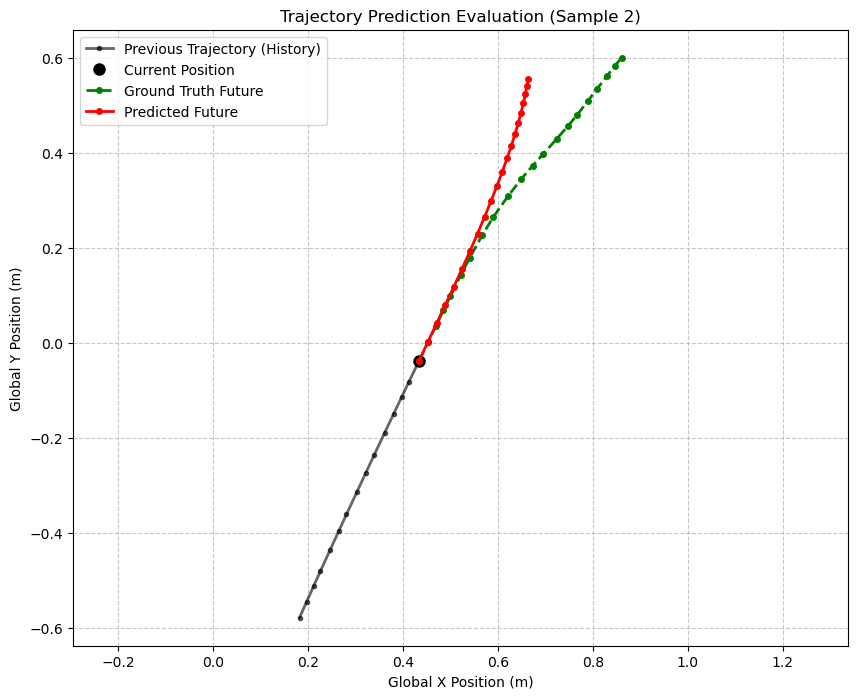

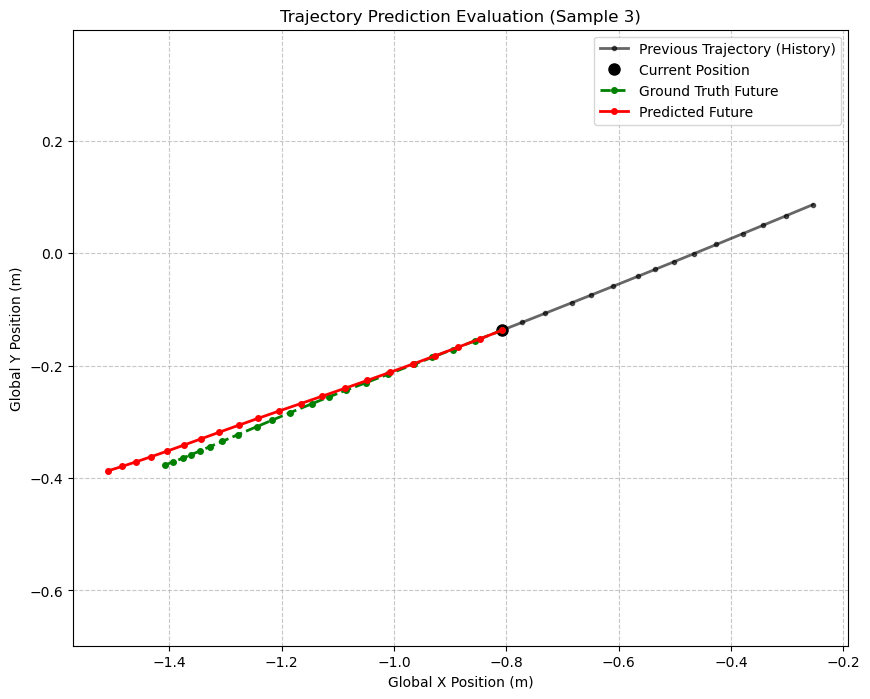

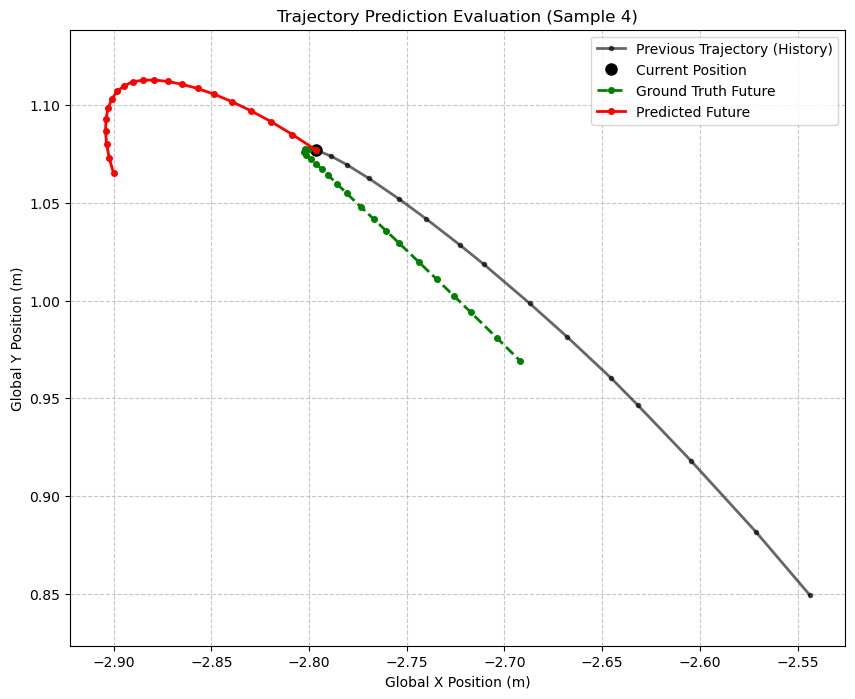

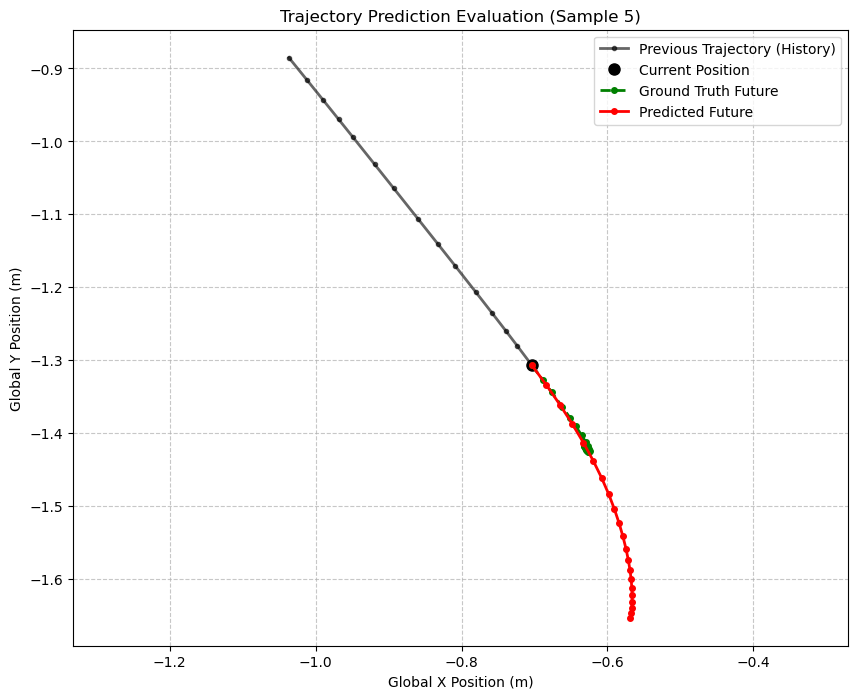

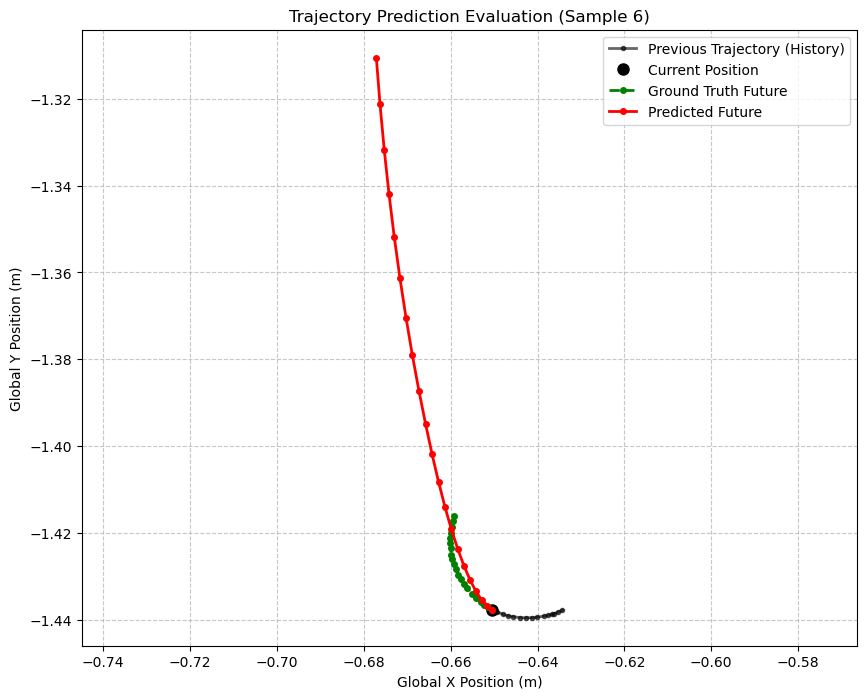

In [15]:
plot_model_evaluation(
    model=loaded_model, 
    dataloader=test_loader, 
    device=device, 
    num_plots=6
)